In [1]:
import geopandas as gpd
import pandas as pd 
import sys
from osgeo import gdal
import numpy as np
import logging
logging.getLogger("pyogrio").setLevel(logging.WARNING)

origin = '/workspace/'
sys.path.append('/media/')

from FieldWaterUseTools.FuncBox.DICT_LIST import EXCLUDE_LIST
from FieldWaterUseTools.FuncBox.FieldFuncis import subset_mask_to_prediction_extent

states = ['Brandenburg', 'Niedersachsen', 'MV', 'NRW', 'Saarland']
state_folders = ['BRB', 'LSA', 'MV', 'NRW', 'SL']
random_seed = 42
_thresh = 0.5

thuenen_path = f"{origin}fields/09_Thuenen_field_maps/"
thuenen_mod = 'CTM_GER_2023_seg_v201'
thuenen_file = f"{thuenen_path}{thuenen_mod}.gpkg"

state = 'Brandenburg'
model = 'FromScratch_dilate_T'
year = '2023'
mask = 'UnMasked'#'ThuenenMasked'
textbound = f"ext_03_bound_01"
polygonized_file = f"{origin}fields/07_Polygonized/{state}/{model}/{year}/{mask}/{mask}_{textbound}_10m.gpkg"
iacs_file = f"{origin}fields/01_IACS/1_Polygons/{state_folders[states.index(state)]}/GSA-DE_{state_folders[states.index(state)]}-{year}.geoparquet"

# for raster comparison of our delineation product
iacs_raster = f"{origin}fields/01_IACS/4_Crop_mask/{state_folders[states.index(state)]}/{year}/IACS_{state_folders[states.index(state)]}_{year}_cropMask_cropMask_lines_touch_false_crop_touch_false_linecrop_LABELLED.tif"
segm_raster = f"{origin}fields/06_Segmentation/{state}/{model}/{year}/{mask}/relabelled/{state}_{model}_{year}_{mask}_{textbound}.tif"

INFO:matplotlib.font_manager:generated new fontManager


In [ ]:
# # make a subset of the reference mask (extent FORCE output) to the extent of the prediction
# subset_mask_to_prediction_extent(iacs_raster, segm_raster, area='')

# # raster comparison
# # label  iacs data
# ds = gdal.Open(f"{iacs_raster.split('.tif')[0]}_prediction_extent_.tif")
# iacs_ras = ds.GetRasterBand(1).ReadAsArray()

# ds = gdal.Open(segm_raster)
# our_ras = ds.GetRasterBand(1).ReadAsArray()
# # here we need the relabelled version --> write away in 07_Polygonize
# assert iacs_ras.shape == our_ras.shape, "Arrays must have the same shape"

# # get count of overlapping fields and export
# pairs = np.stack([iacs_ras, our_ras], axis=2)
# pairs_reshaped = pairs.reshape(-1, 2)
# unique_pairs, counts = np.unique(pairs_reshaped, axis=0, return_counts=True)

# df = pd.DataFrame(unique_pairs, columns=["IACS", ""])
# df["count"] = counts

# df.to_csv(f"{thuenen_path}TEMP/unique_pairs.csv", index=False)

In [ ]:
dat = pd.read_csv(f"{thuenen_path}TEMP/unique_pairs.csv")
# convert data types
dat['IACS'] = dat['IACS'].astype(str)
dat['HU BERLIN'] = dat['HU BERLIN'].astype(str)

# get field sizes
IACS_field_sizes = dat.groupby('IACS')['count'].sum()
HU_field_sizes = dat.groupby('HU BERLIN')['count'].sum()
# get polygons with maximum overlap
IACS_max_interesect = dat.loc[dat.groupby('IACS')['count'].idxmax()]
# HU_max_interesect = dat.loc[dat.groupby('HU BERLIN')['count'].idxmax()]

# merge field sizes to df
IACS_max_interesect = IACS_max_interesect.merge(IACS_field_sizes, on='IACS', how='left')
IACS_max_interesect = IACS_max_interesect.rename(columns={
    'count_x': 'count_intersect',
    'count_y': 'count_IACS_size'
})

IACS_max_interesect = IACS_max_interesect.merge(HU_field_sizes, on='HU BERLIN', how='left')
IACS_max_interesect = IACS_max_interesect.rename(columns={
    'count': 'count_HU_size'
})

# compute union and IoU
IACS_max_interesect['union'] = IACS_max_interesect['count_IACS_size'] + IACS_max_interesect['count_HU_size'] - IACS_max_interesect['count_intersect']
IACS_max_interesect['IoU'] = IACS_max_interesect['count_intersect'] / IACS_max_interesect['union']

# compute proportion of intersect to both polygons
IACS_max_interesect['rel_IACS_overlap'] = IACS_max_interesect['count_intersect'] / IACS_max_interesect['count_IACS_size']
IACS_max_interesect['rel_HU_overlap'] = IACS_max_interesect['count_intersect'] / IACS_max_interesect['count_HU_size']

# filter intersections with background (val=0) and fields < 5 Pixel
maski = IACS_max_interesect['IACS'].eq('0') | IACS_max_interesect['HU BERLIN'].eq('0') | \
    IACS_max_interesect['count_IACS_size'].le(5) | IACS_max_interesect['count_HU_size'].le(5)
IACS_max_interesect = IACS_max_interesect[~maski].copy()

In [2]:
th_iacs_list, th_other_list, mean_our_list, median_our_list, maskL = [], [], [], [], []
for t1 in range(0,6,1):
    for t2 in range(0,6,1):
        t_hu = t1/10
        t_iacs = t2/10
        res_mask = IACS_max_interesect['rel_HU_overlap'].gt(t_hu) & IACS_max_interesect['rel_IACS_overlap'].gt(t_iacs)
        print(IACS_max_interesect[res_mask]['IoU'].mean())

        maskL.append(mask)
        th_iacs_list.append(t_iacs)
        th_other_list.append(t_hu)
        mean_our_list.append(IACS_max_interesect[res_mask]['IoU'].mean())
        median_our_list.append(IACS_max_interesect[res_mask]['IoU'].median())

df = pd.DataFrame({
    'MaskVersion': 'Raster',
    'Threshold on overlap with IACS': th_iacs_list,
    'Threshold on overlap with Other': th_other_list,
    'Mean Our polygons': mean_our_list,
    'Median Our polygons': median_our_list
})

df.to_csv(f"{thuenen_path}TEMP/raster_comparison_result_{mask}.csv", index=False)

NameError: name 'IACS_max_interesect' is not defined

In [3]:
our_polygons = gpd.read_file(polygonized_file)
# thuenen_polygons = gpd.read_file(thuenen_file)
# min_x, min_y, max_x, max_y = our_polygons.total_bounds
# offset = 3000 # in order to avoid cut off artefacts at potential boundary when comparing polygons
# thuenen_subset = thuenen_polygons.cx[(min_x - offset) : max_x, (min_y - offset) : (max_y + offset)].copy()
# thuenen_subset.to_file(f"{thuenen_path}{thuenen_mod}_subset_{state}.gpkg", driver="GPKG")
thuenen_subset = gpd.read_file(f"{thuenen_path}{thuenen_mod}_subset_{state}.gpkg")
iacs_polygons = gpd.read_parquet(iacs_file)

# rename IDs to prevent confusion when intersecting
our_polygons['OUR_FIELD_ID'] = our_polygons['FieldID']
our_polygons = our_polygons.drop(columns=['FieldID'])
our_polygons['OUR_AREA_ha'] = our_polygons.geometry.area / 10000

thuenen_subset['THUENEN_FIELD_ID'] = thuenen_subset['id']
thuenen_subset['THUENEN_AREA_ha'] = thuenen_subset['area_ha']
thuenen_subset = thuenen_subset.drop(columns=['id', 'area_ha'])

iacs_polygons['IACS_FIELD_ID'] = iacs_polygons['field_id']
iacs_polygons['IACS_AREA_ha'] = iacs_polygons['field_size']
iacs_polygons = iacs_polygons.drop(columns=['field_size', 'field_id'])

In [ ]:
################################### 
### There is an issue with our polygons. In the polygonization process, some fields at the border of states are cut into multiple smaller fields with the same id.
### in the scope of validation they can be ignored, but the behaviour should be fixed  !!!!
### Fix to be implemented: interesect keep cutted polygons entirely, at the moment, they are neglected completely from samples

duplicates = our_polygons[our_polygons["OUR_FIELD_ID"].isin(our_polygons["OUR_FIELD_ID"][our_polygons["OUR_FIELD_ID"].duplicated()])].sort_values("OUR_FIELD_ID")
our_polygons[our_polygons["OUR_FIELD_ID"].isin(our_polygons["OUR_FIELD_ID"][our_polygons["OUR_FIELD_ID"].duplicated()])].sort_values("OUR_FIELD_ID")
kill_IDs = duplicates['OUR_FIELD_ID'].unique().tolist()

# fram_pols = our_polygons[our_polygons['OUR_FIELD_ID'].isin(kill_IDs)].copy()
# fram_pols.to_file(f"{thuenen_path}TEMP/fram_pols.gpkg", driver="GPKG")


In [ ]:
our_polygons_filtered = our_polygons[~our_polygons['OUR_FIELD_ID'].isin(kill_IDs)].copy()
our_polygons_filtered = our_polygons_filtered[our_polygons_filtered['OUR_AREA_ha'] > 0.05] # fields size is in ha -> should be larger than 5 pixel

# check projections
if thuenen_subset.crs != iacs_polygons.crs:
    print('reprojecting thuenen')
    thuenen_subset = thuenen_subset.to_crs(iacs_polygons.crs)
else:
    print('thuenen and iacs polygons have same CRS')

if our_polygons_filtered.crs != iacs_polygons.crs:
    print('reprojecting our polygons')
    our_polygons_filtered = our_polygons_filtered.to_crs(iacs_polygons.crs)
else:
    print('ours and iacs polygons have same CRS')

# draw a sample from IACS after subsetting to 5 pixel threshold and excluding polygons with attributes listed on EXCLUDE_LIST
iacs_polygons_filtered = iacs_polygons[~iacs_polygons['EC_hcat_n'].isin(EXCLUDE_LIST)].copy()
iacs_polygons_filtered = iacs_polygons_filtered[iacs_polygons_filtered['IACS_AREA_ha'] > 0.05] # fields size is in ha -> should be larger than 5 pixel
iacs_polygons_filtered['decile'] = pd.qcut(iacs_polygons_filtered['IACS_AREA_ha'], q=10, labels=False)

n_per_decile = 1500
iacs_sample = (
    iacs_polygons_filtered
    .groupby('decile', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), n_per_decile), random_state=random_seed), include_groups=False)
    .reset_index(drop=True)
)

iacs_sample.to_file(f"{thuenen_path}TEMP/iacs_sample_{mask}.gpkg", driver="GPKG")

thuenen and iacs polygons have same CRS
ours and iacs polygons have same CRS


<Axes: >

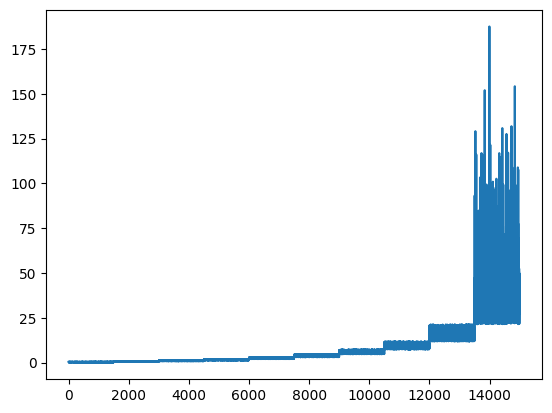

In [15]:
iacs_sample['IACS_AREA_ha'].plot()

In [5]:
# intersect our polygons with sample with IACS
intersections_IACS_OURS = gpd.overlay(our_polygons_filtered, iacs_sample, how='intersection')
intersections_IACS_OURS['OVERLAP_AREA_ha'] = intersections_IACS_OURS.geometry.area / 10000
intersections_IACS_OURS = intersections_IACS_OURS.drop(columns=['crop_code', 'crop_name', 'EC_trans_n']) # make it in ipynb more readable

# calculate ratio of overlap (in regards to IACS and to our polygons) and keep the intersecting polygons with highest overlap
intersections_IACS_OURS['OVERLAP_AREA_with_IACS_relative'] = intersections_IACS_OURS['OVERLAP_AREA_ha'] / intersections_IACS_OURS['IACS_AREA_ha']
intersections_IACS_OURS.loc[intersections_IACS_OURS['OVERLAP_AREA_with_IACS_relative'] > 1,'OVERLAP_AREA_with_IACS_relative'] = 1

intersections_IACS_OURS['OVERLAP_AREA_with_OURS_relative'] = intersections_IACS_OURS['OVERLAP_AREA_ha'] / intersections_IACS_OURS['OUR_AREA_ha']
intersections_IACS_OURS.loc[intersections_IACS_OURS['OVERLAP_AREA_with_OURS_relative'] > 1,'OVERLAP_AREA_with_OURS_relative'] = 1

intersections_IACS_OURS.to_file(f"{thuenen_path}TEMP/intersects_ours_{mask}.gpkg", driver="GPKG")

# intersect thuenen polygons with sample with IACS
intersections_IACS_TH = gpd.overlay(thuenen_subset, iacs_sample, how='intersection')
intersections_IACS_TH['OVERLAP_AREA_ha'] = intersections_IACS_TH.geometry.area / 10000
intersections_IACS_TH = intersections_IACS_TH.drop(columns=['crop_code', 'crop_name', 'EC_trans_n']) # make it in ipynb more readable

# calculate ratio of overlap (in regards to IACS and to our polygons) and keep the intersecting polygons with highest overlap
intersections_IACS_TH['OVERLAP_AREA_with_IACS_relative'] = intersections_IACS_TH['OVERLAP_AREA_ha'] / intersections_IACS_TH['IACS_AREA_ha']
intersections_IACS_TH.loc[intersections_IACS_TH['OVERLAP_AREA_with_IACS_relative'] > 1,'OVERLAP_AREA_with_IACS_relative'] = 1

intersections_IACS_TH['OVERLAP_AREA_with_TH_relative'] = intersections_IACS_TH['OVERLAP_AREA_ha'] / intersections_IACS_TH['THUENEN_AREA_ha']
intersections_IACS_TH.loc[intersections_IACS_TH['OVERLAP_AREA_with_TH_relative'] > 1,'OVERLAP_AREA_with_TH_relative'] = 1

intersections_IACS_TH.to_file(f"{thuenen_path}TEMP/intersects_th_{mask}.gpkg", driver="GPKG")

In [ ]:
th_iacs_list, th_other_list, mean_thuen_list, mean_our_list, median_thuen_list, median_our_list, maskL = [], [], [], [], [], [], []

for threshold1 in range(0,6,1):
    for threshold2 in range(0,6,1):
        thresh_iacs = threshold1 / 10
        thresh_other = threshold2 / 10
        best_match_ours = intersections_IACS_OURS[(intersections_IACS_OURS['OVERLAP_AREA_with_IACS_relative'] > thresh_iacs) & 
                                                (intersections_IACS_OURS['OVERLAP_AREA_with_OURS_relative'] > thresh_other)]

        if best_match_ours['OUR_FIELD_ID'].duplicated().sum() > 0:
            print(best_match_ours['OUR_FIELD_ID'].duplicated().sum())
            dupl_ID = best_match_ours[best_match_ours['OUR_FIELD_ID'].duplicated()]['OUR_FIELD_ID']
            ind1 = best_match_ours[best_match_ours['OUR_FIELD_ID'].isin(dupl_ID)]['OVERLAP_AREA_ha'].idxmin()
            best_match_ours = best_match_ours.drop(index=ind1)

        # compute union for best matches
        best_match_ours_df = best_match_ours.drop(columns=['geometry']).copy()
        merged = best_match_ours_df.merge(
            our_polygons[['OUR_FIELD_ID', 'geometry']].rename(columns={"geometry": "geometry_OURS"}),
            on='OUR_FIELD_ID',
            how='left')
       

        merged = merged.merge(
            iacs_sample[["IACS_FIELD_ID", "geometry"]].rename(columns={"geometry": "geometry_IACS"}),
            on="IACS_FIELD_ID",
            how="left"
        )

        merged["geometry"] = merged.apply(
            lambda row: row["geometry_OURS"].union(row["geometry_IACS"]),
            axis=1
        )

        union_IACS_OURS = gpd.GeoDataFrame(merged, geometry="geometry", crs=our_polygons_filtered.crs)
        union_IACS_OURS = union_IACS_OURS.drop(columns=['geometry_OURS', 'geometry_IACS'])
        union_IACS_OURS['UNION_AREA_ha'] = union_IACS_OURS.geometry.area / 10000
        union_IACS_OURS['IoU'] = union_IACS_OURS['OVERLAP_AREA_ha'] / union_IACS_OURS['UNION_AREA_ha']
        union_IACS_OURS.to_file(f"{thuenen_path}TEMP/union_IACS_OURS_iacs{thresh_iacs}_other{thresh_other}_{mask}.gpkg", driver="GPKG")


        best_match_TH = intersections_IACS_TH[(intersections_IACS_TH['OVERLAP_AREA_with_IACS_relative'] > thresh_iacs) & 
                                (intersections_IACS_TH['OVERLAP_AREA_with_TH_relative'] > thresh_other)]

        if best_match_TH['THUENEN_FIELD_ID'].duplicated().sum() > 0:
            dupl_ID2 = best_match_TH[best_match_TH['THUENEN_FIELD_ID'].duplicated()]['THUENEN_FIELD_ID']
            ind2 = best_match_TH[best_match_TH['THUENEN_FIELD_ID'].isin(dupl_ID2)]['OVERLAP_AREA_ha'].idxmin()
            best_match_TH = best_match_TH.drop(index=ind2)

        # compute union for best matches
        best_match_TH_df = best_match_TH.drop(columns=['geometry']).copy()
        merged = best_match_TH_df.merge(
            thuenen_subset[['THUENEN_FIELD_ID', 'geometry']].rename(columns={"geometry": "geometry_TH"}),
            on='THUENEN_FIELD_ID',
            how='left')

        merged = merged.merge(
            iacs_sample[[ "IACS_FIELD_ID", "geometry" ]].rename(columns={"geometry": "geometry_IACS"}),
            on="IACS_FIELD_ID",
            how="left"
        )

        merged["geometry"] = merged.apply(
            lambda row: row["geometry_TH"].union(row["geometry_IACS"]),
            axis=1
        )

        union_IACS_TH = gpd.GeoDataFrame(merged, geometry="geometry", crs=thuenen_subset.crs)
        union_IACS_TH = union_IACS_TH.drop(columns=['geometry_TH', 'geometry_IACS'])
        union_IACS_TH['UNION_AREA_ha'] = union_IACS_TH.geometry.area / 10000
        union_IACS_TH['IoU'] = union_IACS_TH['OVERLAP_AREA_ha'] / union_IACS_TH['UNION_AREA_ha']
        union_IACS_TH.to_file(f"{thuenen_path}TEMP/union_IACS_THUENEN_{thresh_iacs}_other{thresh_other}_{mask}.gpkg", driver="GPKG")

        maskL.append(mask)
        th_iacs_list.append(thresh_iacs)
        th_other_list.append(thresh_other)
        mean_thuen_list.append(union_IACS_TH['IoU'].mean())
        mean_our_list.append(union_IACS_OURS['IoU'].mean())
        median_thuen_list.append(union_IACS_TH['IoU'].median())
        median_our_list.append(union_IACS_OURS['IoU'].median())
        print(f"applied threshold on IACS: {thresh_iacs}, applied threshold on others: {thresh_other}")
        print(f"mean of our polygons: {union_IACS_OURS['IoU'].mean()}")
        print(f"mean of gideons polygons: {union_IACS_TH['IoU'].mean()}")
        print('----------------------')

df = pd.DataFrame({
    'MaskVersion': maskL,
    'Threshold on overlap with IACS': th_iacs_list,
    'Threshold on overlap with Other': th_other_list,
    'Mean Thuenen polygons': mean_thuen_list,
    'Median Thuenen polygons': median_thuen_list,
    'Mean Our polygons': mean_our_list,
    'Median Our polygons': median_our_list
})

#df.to_csv(f"{thuenen_path}TEMP/comparison_result_{mask}_smallsmall_sample.csv", index=False)

applied threshold on IACS: 0.0, applied threshold on others: 0.0
mean of our polygons: 0.17894498841384845
mean of gideons polygons: 0.11341134391931408
----------------------
applied threshold on IACS: 0.0, applied threshold on others: 0.1
mean of our polygons: 0.36746076283588913
mean of gideons polygons: 0.20703288534021896
----------------------
applied threshold on IACS: 0.0, applied threshold on others: 0.2
mean of our polygons: 0.39351594546592983
mean of gideons polygons: 0.22021151505479217
----------------------
applied threshold on IACS: 0.0, applied threshold on others: 0.3
mean of our polygons: 0.4090345820199708
mean of gideons polygons: 0.2270787054050669
----------------------
applied threshold on IACS: 0.0, applied threshold on others: 0.4
mean of our polygons: 0.41669580048387106
mean of gideons polygons: 0.2321134751645714
----------------------
applied threshold on IACS: 0.0, applied threshold on others: 0.5
mean of our polygons: 0.43082829269139117
mean of gideons 

In [ ]:
# this was used before the union step to filter

# idx = intersections_IACS_OURS.groupby("IACS_FIELD_ID")["OVERLAP_AREA_with_IACS_relative"].idxmax()
# best_match_ours = intersections_IACS_OURS.loc[idx].copy()
# best_match_ours = best_match_ours[best_match_ours["OVERLAP_AREA_with_IACS_relative"] > thresh]

# best_match_ours.to_file(f"{thuenen_path}TEMP/best_match_ours.gpkg", driver="GPKG")

In [ ]:
# idx = intersections_IACS_TH.groupby("IACS_FIELD_ID")["OVERLAP_AREA_with_IACS_relative"].idxmax()
# best_match_TH = intersections_IACS_TH.loc[idx].copy()
# best_match_TH = best_match_TH[best_match_TH["OVERLAP_AREA_with_IACS_relative"] > thresh]

# best_match_TH.to_file(f"{thuenen_path}TEMP/best_match_ours.gpkg", driver="GPKG")